In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("../data/telco_clean.csv")

print("Shape:", df.shape)
df.head()

Shape: (7021, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7021 non-null   int64  
 1   tenure                                 7021 non-null   int64  
 2   MonthlyCharges                         7021 non-null   float64
 3   TotalCharges                           7021 non-null   float64
 4   Churn                                  7021 non-null   int64  
 5   gender_Male                            7021 non-null   bool   
 6   Partner_Yes                            7021 non-null   bool   
 7   Dependents_Yes                         7021 non-null   bool   
 8   PhoneService_Yes                       7021 non-null   bool   
 9   MultipleLines_No phone service         7021 non-null   bool   
 10  MultipleLines_Yes                      7021 non-null   bool   
 11  InternetService

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7021.000000,7021.000000,7021.000000,7021.000000,7021.000000
mean,0.162512,32.469449,64.851894,2288.954490,0.264492
std,0.368947,24.534965,30.069001,2265.319449,0.441094
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.750000,411.150000,0.000000
50%,0.000000,29.000000,70.400000,1400.550000,0.000000
75%,0.000000,55.000000,89.900000,3801.700000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [4]:
df.isnull().sum()

SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMo

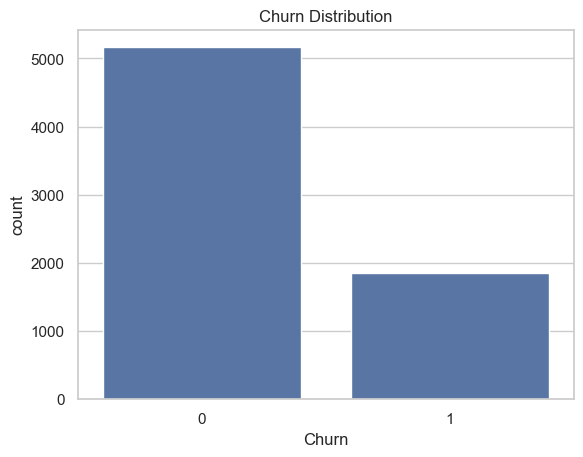

Churn
0    0.735508
1    0.264492
Name: proportion, dtype: float64

In [5]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

df["Churn"].value_counts(normalize=True)

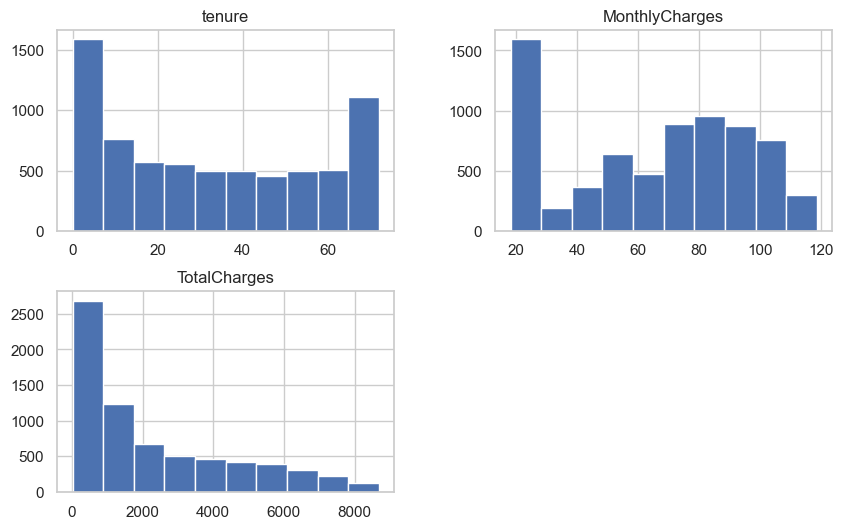

In [6]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[num_cols].hist(figsize=(10,6))
plt.show()

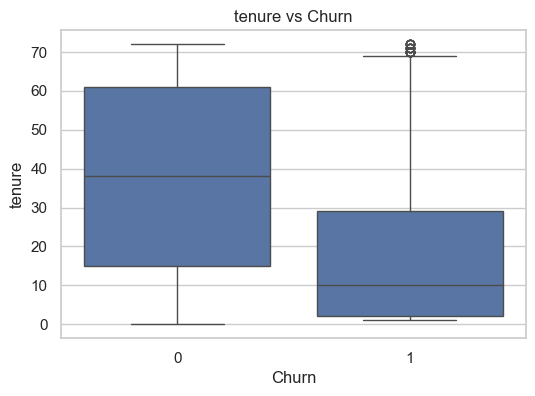

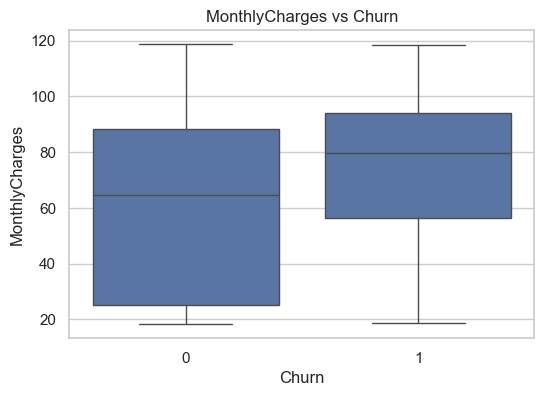

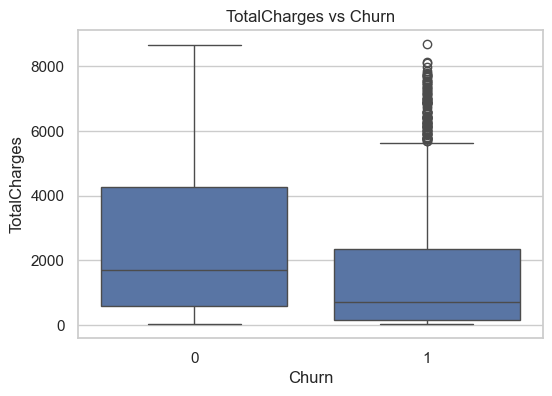

In [7]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

In [17]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Churn", data=df)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.show()

In [10]:
# Avg Monthly Charge
df["AvgMonthlyCharge"] = df["TotalCharges"] / (df["tenure"] + 1)

# Tenure Bucket
df["TenureBucket"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 36, 72],
    labels=["Short", "Medium", "Long"]
)

# -----------------------------
# Num Addons (FIXED FOR DUMMIES)
# -----------------------------
addon_cols = [col for col in df.columns if "_Yes" in col and any(
    service in col for service in [
        "OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies"
    ]
)]

df["NumAddons"] = df[addon_cols].sum(axis=1)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlyCharge,TenureBucket,NumAddons
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,True,False,True,False,14.925000,Short,1
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,True,False,False,False,False,True,53.985714,Medium,2
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,True,False,False,True,36.050000,Short,2
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,True,False,False,False,False,False,40.016304,Long,3
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,True,False,True,False,50.550000,Short,0


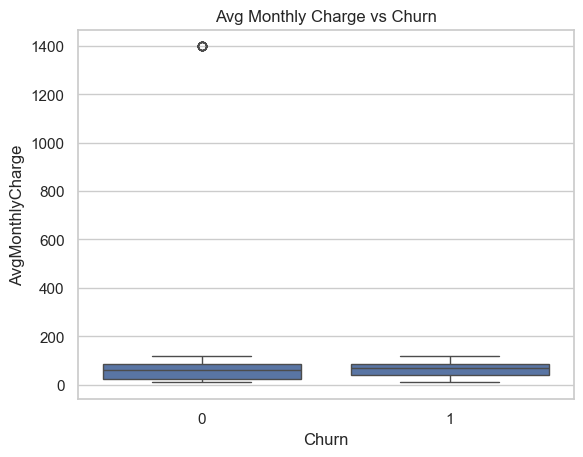

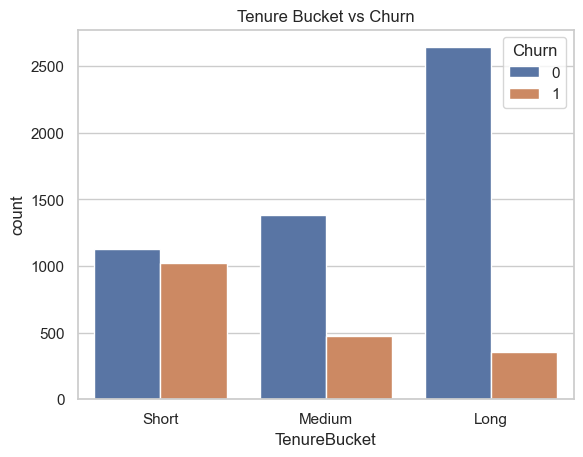

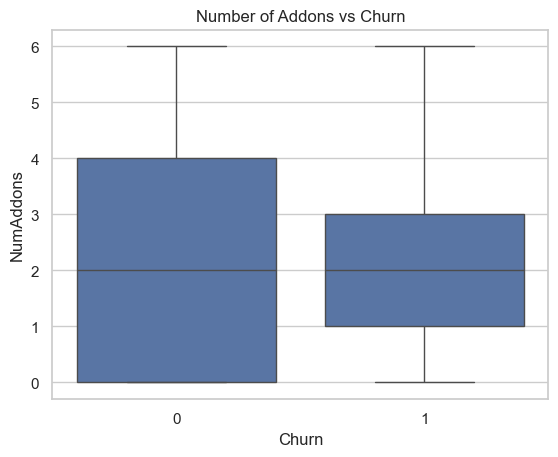

In [11]:
sns.boxplot(x="Churn", y="AvgMonthlyCharge", data=df)
plt.title("Avg Monthly Charge vs Churn")
plt.show()

sns.countplot(x="TenureBucket", hue="Churn", data=df)
plt.title("Tenure Bucket vs Churn")
plt.show()

sns.boxplot(x="Churn", y="NumAddons", data=df)
plt.title("Number of Addons vs Churn")
plt.show()

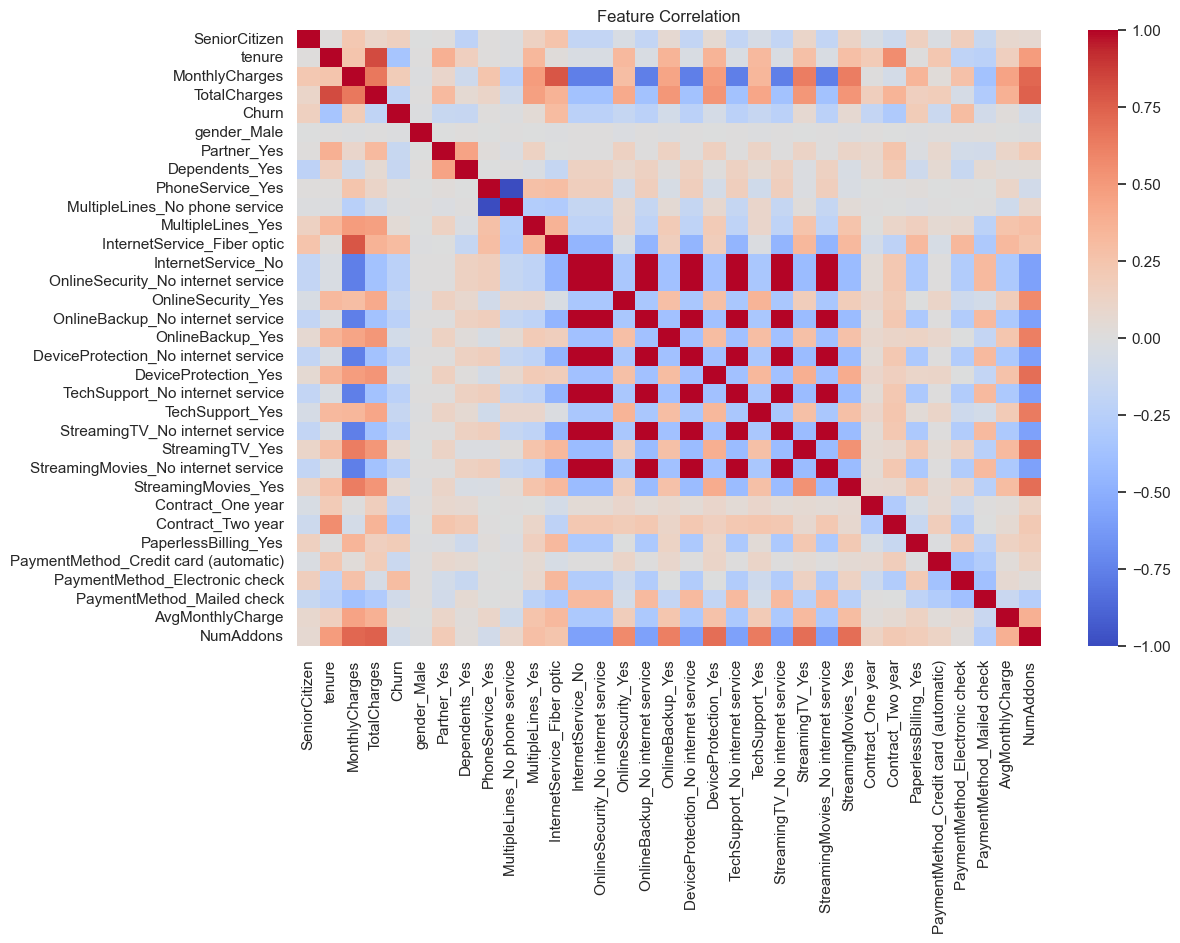

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

### Key Insights

- Customers with low tenure are more likely to churn.
- Higher monthly charges increase churn probability.
- Customers with fewer add-on services tend to churn more.
- Short-term contracts (month-to-month) show higher churn.
- Dataset is imbalanced (~26% churn), hence SMOTE was applied.